# EDA — Customer Support Ticket Dataset

Este notebook contém a Análise Exploratória de Dados (EDA) inicial do dataset
que servirá de base para o sistema de atendimento ao cliente construído ao
longo do bloco (classificação de intenção de tickets de suporte).

## Documentação técnica do dataset

**Fonte (origem):** [Customer Support Ticket Dataset](https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset/data),
publicado no Kaggle pelo usuário `suraj520`. É um dataset **sintético**,
gerado programaticamente para simular tickets de um sistema de suporte ao
cliente (não são dados reais de uma empresa). Evidências dessa origem
sintética aparecem ao longo desta EDA (ex.: distribuições quase perfeitamente
balanceadas entre categorias e inconsistências de timestamp, ver seção de
qualidade dos dados).

**Licença:** [CC0: Public Domain](https://creativecommons.org/publicdomain/zero/1.0/)
(conforme indicado na página do dataset no Kaggle). Isso significa que o
dataset está em domínio público — pode ser usado, modificado e redistribuído
livremente, sem exigência de atribuição, o que respalda seu uso e
redistribuição neste repositório (arquivo em `data/customer_support_tickets.csv`).

**Principais características:**
- 8.469 tickets (linhas) e 17 colunas.
- Colunas de identificação/perfil do cliente: `Ticket ID`, `Customer Name`,
  `Customer Email`, `Customer Age`, `Customer Gender`.
- Colunas do produto: `Product Purchased`, `Date of Purchase` (42 produtos
  distintos, ex.: GoPro Hero, LG Smart TV, Canon EOS, Amazon Echo).
- Colunas do ticket em si: `Ticket Type` (5 categorias), `Ticket Subject`
  (16 categorias), `Ticket Description` (texto livre, com boilerplate),
  `Ticket Status` (Open / Pending Customer Response / Closed), `Resolution`
  (texto livre, preenchido só quando `Closed`), `Ticket Priority` (Low /
  Medium / High / Critical), `Ticket Channel` (Email / Phone / Chat / Social
  media).
- Colunas de tempo/SLA: `First Response Time`, `Time to Resolution`
  (timestamps, preenchidos condicionalmente ao status).
- Coluna de satisfação: `Customer Satisfaction Rating` (1–5, só para tickets
  `Closed`).

**Motivo da escolha do dataset:**
1. O texto livre (`Ticket Description`) combinado com campos categóricos
   estruturados (`Ticket Type`, `Ticket Subject`) é exatamente o formato de
   entrada que o futuro agente de atendimento (classificador de intenção)
   precisará processar.
2. O tamanho (aprox. 8.5 mil linhas) é grande o suficiente para treinar um
   classificador de texto simples, mas pequeno o suficiente para rodar EDA e
   experimentos rapidamente em uma máquina local.
3. O dataset tem problemas de qualidade realistas (valores ausentes
   estruturais, inconsistências de timestamp, placeholders de template não
   substituídos), é ótimo para praticar limpeza e validação de dados antes de
   qualquer modelagem, e também para discutir os riscos de treinar um modelo
   sobre dados sintéticos e desbalanceamentos artificiais, que é quando o
   desenvolvedor determina proporções específicas nos dados antes de treinar
   o modelo.
4. Os campos de canal, prioridade e status permitem, no futuro, enriquecer o
   agente com regras de roteamento/priorização além da simples classificação
   de intenção.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

DATA_PATH = "../data/customer_support_tickets.csv"


## 1. Compreensão do problema e do dataset

**Problema de negócio:** uma equipe de atendimento ao cliente recebe tickets
de suporte por múltiplos canais (email, telefone, chat, redes sociais) e
precisa identificar rapidamente a **intenção** por trás de cada ticket
(ex.: pedido de reembolso, dúvida técnica, cancelamento) para roteá-lo à
fila correta e priorizá-lo. O objetivo final do bloco é construir uma API
com um modelo que, dado o texto de um ticket, prevê essa intenção
automaticamente.

**Papel de cada coluna nesse problema:**
- **Feature candidata principal:** `Ticket Description` (texto livre do
  cliente), é o que estará disponível no momento da predição.
- **Rótulo candidato:** `Ticket Type` e/ou `Ticket Subject`, representam a
  "intenção" que o modelo deverá aprender a prever.
- **Metadados auxiliares:** `Product Purchased`, `Ticket Channel`,
  `Customer Age`/`Gender` podem virar features adicionais.
- **Vazamento de informação (data leakage) a evitar no futuro:** `Resolution`,
  `Time to Resolution` e `Customer Satisfaction Rating` só existem **depois**
  que o ticket é resolvido, não estarão disponíveis no momento em que a
  intenção precisa ser prevista, então não podem ser usadas como features de
  um classificador de intenção.


## 2. Inspeção inicial

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape (linhas, colunas):", df.shape)
df.head(3)


Shape (linhas, colunas): (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [4]:
df.describe(include=[np.number])


,Ticket ID,Customer Age,Customer Satisfaction Rating
count,8469.000000,8469.000000,2769.000000
mean,4235.000000,44.026804,2.991333
std,2444.934048,15.296112,1.407016
min,1.000000,18.000000,1.000000
25%,2118.000000,31.000000,2.000000
50%,4235.000000,44.000000,3.000000
75%,6352.000000,57.000000,4.000000
max,8469.000000,70.000000,5.000000


In [5]:
# Cardinalidade das colunas categóricas / de texto
df.select_dtypes(include="object").nunique().sort_values(ascending=False)


C:\Users\Jonathan.Scottini\AppData\Local\Temp\ipykernel_30076\2332808989.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").nunique().sort_values(ascending=False)


Customer Email         8320
Ticket Description     8077
Customer Name          8028
First Response Time    5470
Resolution             2769
Time to Resolution     2728
Date of Purchase        730
Product Purchased        42
Ticket Subject           16
Ticket Type               5
Ticket Priority           4
Ticket Channel            4
Customer Gender           3
Ticket Status             3
dtype: int64

## 3. Verificação da qualidade dos dados

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0")


,missing_count,missing_pct
Resolution,5700,67.3
First Response Time,2819,33.3
Time to Resolution,5700,67.3
Customer Satisfaction Rating,5700,67.3


As três colunas com valores ausentes (`Resolution`, `Time to Resolution`,
`Customer Satisfaction Rating`) têm **exatamente 5.700 valores nulos** cada.
A hipótese é que a ausência não é aleatória (MNAR — *missing not at random*),
e sim **estrutural**: essas colunas só fazem sentido para tickets já
resolvidos. A célula abaixo confirma isso cruzando com `Ticket Status`.

In [7]:
print("Nulos em Resolution por status:")
print(pd.crosstab(df["Ticket Status"], df["Resolution"].isnull()))
print()
print("Nulos em First Response Time por status:")
print(pd.crosstab(df["Ticket Status"], df["First Response Time"].isnull()))


Nulos em Resolution por status:
Resolution                 False  True 
Ticket Status                          
Closed                      2769      0
Open                           0   2819
Pending Customer Response      0   2881

Nulos em First Response Time por status:
First Response Time        False  True 
Ticket Status                          
Closed                      2769      0
Open                           0   2819
Pending Customer Response   2881      0


Como podemos ver: `Resolution`/`Time to Resolution`/`Customer Satisfaction Rating`
são nulos em **100% dos tickets não-`Closed`** e preenchidos em 100% dos
`Closed`. Da mesma forma, `First Response Time` só é nulo quando o status é
`Open` (ainda não houve nenhuma resposta). Ou seja: não é um problema de
qualidade a ser corrigido, é o comportamento esperado do domínio,
a limpeza deve **preservar** esses nulos e, no máximo, derivar uma flag
booleana a partir deles.

In [8]:
print("Linhas duplicadas (exact match):", df.duplicated().sum())
print("Ticket IDs duplicados:", df["Ticket ID"].duplicated().sum())


Linhas duplicadas (exact match): 0
Ticket IDs duplicados: 0


In [9]:
placeholder_bug = df["Ticket Description"].str.contains(r"\{product_purchased\}", regex=True)
print(f"Descrições com placeholder de template não substituído '{{product_purchased}}': "
      f"{placeholder_bug.sum()} de {len(df)} ({placeholder_bug.mean():.1%})")
df.loc[placeholder_bug, "Ticket Description"].iloc[0]


Descrições com placeholder de template não substituído '{product_purchased}': 8469 de 8469 (100.0%)


"I'm having an issue with the {product_purchased}. Please assist.\n\nYour billing zip code is: 71701.\n\nWe appreciate that you have requested a website address.\n\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists."

In [10]:
# Inconsistência temporal: em teoria "Time to Resolution" deveria ser >= "First Response Time".
ts = df.dropna(subset=["First Response Time", "Time to Resolution"]).copy()
ts["First Response Time"] = pd.to_datetime(ts["First Response Time"])
ts["Time to Resolution"] = pd.to_datetime(ts["Time to Resolution"])
inconsistent = ts["Time to Resolution"] < ts["First Response Time"]
print(f"Tickets fechados com resolução ANTES da primeira resposta: "
      f"{inconsistent.sum()} de {len(ts)} ({inconsistent.mean():.1%})")
ts.loc[inconsistent, ["First Response Time", "Time to Resolution"]].head()


Tickets fechados com resolução ANTES da primeira resposta: 1365 de 2769 (49.3%)


,First Response Time,Time to Resolution
3,2023-06-01 07:29:40,2023-06-01 01:57:40
10,2023-06-01 17:46:49,2023-05-31 23:51:49
11,2023-06-01 12:05:51,2023-06-01 09:27:51
14,2023-06-01 06:22:55,2023-05-31 23:08:55
16,2023-06-01 19:46:59,2023-06-01 15:58:59


**Resumo dos problemas de qualidade encontrados:**
1. Sem duplicatas de `Ticket ID` e sem linhas 100% duplicadas — ok.
2. Nulos estruturais (não é erro) em `Resolution`, `Time to Resolution` e
   `Customer Satisfaction Rating` para tickets ainda não `Closed`.
3. **Bug de template:** 100% das descrições contêm o placeholder literal
   `{product_purchased}` não substituído pelo nome real do produto — um
   defeito de geração de texto no dataset sintético.
4. **Inconsistência temporal:** uma fração relevante dos tickets fechados
   tem `Time to Resolution` **anterior** a `First Response Time`, o que é
   logicamente impossível em um fluxo real de atendimento — evidência de que
   os timestamps foram gerados aleatoriamente, sem garantir ordem causal.
   Por isso, `First Response Time`/`Time to Resolution` **não devem ser
   usados** para calcular SLAs reais nesta EDA. Ficam registrados aqui como
   limitação do dataset.


## 4. Limpeza e preparação dos dados

Com base no diagnóstico acima, serão feitas apenas conversões de tipo e a criação de colunas derivadas úteis
para a análise univariada e para etapas futuras de modelagem. **Nenhuma linha é removida** e **nenhum campo nulo é
alterado** (imputar inventaria uma resolução/satisfação que não existe).


In [11]:
df_clean = df.copy()

# 4.1 Tipos de data/hora
df_clean["Date of Purchase"] = pd.to_datetime(df_clean["Date of Purchase"])
df_clean["First Response Time"] = pd.to_datetime(df_clean["First Response Time"])
df_clean["Time to Resolution"] = pd.to_datetime(df_clean["Time to Resolution"])

# 4.2 Categóricas como category (mais eficiente e explícito)
for col in ["Ticket Type", "Ticket Subject", "Ticket Status", "Ticket Priority",
            "Ticket Channel", "Customer Gender"]:
    df_clean[col] = df_clean[col].astype("category")

# 4.3 Flags derivadas a partir dos nulos estruturais (em vez de imputar)
df_clean["is_closed"] = df_clean["Ticket Status"].eq("Closed")
df_clean["has_satisfaction_rating"] = df_clean["Customer Satisfaction Rating"].notna()

# 4.4 Remove o placeholder de template não substituído para uma versão "limpa" do texto
df_clean["description_clean"] = (
    df_clean["Ticket Description"].str.replace(r"\{product_purchased\}", "the product", regex=True)
)
df_clean["description_length"] = df_clean["Ticket Description"].str.len()

# 4.5 Ano/mês da compra, útil para eventuais análises temporais futuras
df_clean["purchase_year"] = df_clean["Date of Purchase"].dt.year
df_clean["purchase_month"] = df_clean["Date of Purchase"].dt.month

df_clean.dtypes


Ticket ID                                int64
Customer Name                              str
Customer Email                             str
Customer Age                             int64
Customer Gender                       category
Product Purchased                          str
Date of Purchase                datetime64[us]
Ticket Type                           category
Ticket Subject                        category
Ticket Description                         str
Ticket Status                         category
Resolution                                 str
Ticket Priority                       category
Ticket Channel                        category
First Response Time             datetime64[us]
Time to Resolution              datetime64[us]
Customer Satisfaction Rating           float64
is_closed                                 bool
has_satisfaction_rating                   bool
description_clean                          str
description_length                       int64
purchase_year

In [12]:
# Checagem pós-limpeza: mesma contagem de linhas, nulos estruturais preservados
assert len(df_clean) == len(df)
assert df_clean["Customer Satisfaction Rating"].isnull().sum() == 5700
df_clean[["Ticket Status", "is_closed", "has_satisfaction_rating",
          "description_length", "purchase_year"]].head()


,Ticket Status,is_closed,has_satisfaction_rating,description_length,purchase_year
0,Pending Customer Response,False,False,284,2021
1,Pending Customer Response,False,False,282,2021
2,Closed,True,True,275,2020
3,Closed,True,True,262,2020
4,Closed,True,True,333,2020


## 5. Análise Univariada

Distribuição das principais variáveis categóricas e numéricas do dataset.

### 5.1 Variáveis numéricas

Para cada variável numérica: (1) estatísticas de centro (média, mediana, mínimo,
máximo), (2) medidas de dispersão (quartis, variância, desvio padrão) e (3) a
distribuição via histograma.

In [13]:
numeric_cols = ["Customer Age", "Customer Satisfaction Rating"]

for col in numeric_cols:
    serie = df_clean[col].dropna()
    print(f"--- {col} ---")
    print(f"média: {serie.mean():.2f} | mediana: {serie.median():.2f} | "
          f"mínimo: {serie.min():.2f} | máximo: {serie.max():.2f}")
    q1, q2, q3 = serie.quantile([0.25, 0.5, 0.75])
    print(f"Q1: {q1:.2f} | Q2 (mediana): {q2:.2f} | Q3: {q3:.2f}")
    print(f"variância: {serie.var():.2f} | desvio padrão: {serie.std():.2f}")
    print()


--- Customer Age ---
média: 44.03 | mediana: 44.00 | mínimo: 18.00 | máximo: 70.00
Q1: 31.00 | Q2 (mediana): 44.00 | Q3: 57.00
variância: 233.97 | desvio padrão: 15.30

--- Customer Satisfaction Rating ---
média: 2.99 | mediana: 3.00 | mínimo: 1.00 | máximo: 5.00
Q1: 2.00 | Q2 (mediana): 3.00 | Q3: 4.00
variância: 1.98 | desvio padrão: 1.41



**Observações (variáveis numéricas):**
- `Customer Age`: média (~44) e mediana (~44) praticamente coincidem, e o
  desvio padrão (~15.3) é compatível com um intervalo uniforme de 18 a 70 anos,
  não há assimetria nem indício de outliers de idade.
- `Customer Satisfaction Rating` (calculada apenas sobre os 2.769 tickets
  `Closed`): média e mediana (~3) também coincidem, com desvio padrão baixo
  (~1.4) em uma escala discreta de 1 a 5, distribuição aproximadamente
  simétrica, sem uma nota dominante.
- Em ambos os casos, média ≈ mediana sugere baixa assimetria, reforçando a
  leitura de que o dataset foi gerado sinteticamente com distribuições
  próximas do uniforme, e não amostrado de um cenário real de suporte.

### 5.2 Variáveis categóricas

Para cada variável categórica: (1) quantidade de categorias, (2) frequência
absoluta e relativa (%) e (3) a categoria mais frequente (moda).

In [14]:
categorical_cols = ["Ticket Type", "Ticket Subject", "Ticket Status", "Ticket Priority",
                    "Ticket Channel", "Customer Gender", "Product Purchased"]

for col in categorical_cols:
    serie = df_clean[col]
    freq_abs = serie.value_counts()
    freq_rel = (serie.value_counts(normalize=True) * 100).round(2)
    moda = serie.mode()[0]
    print(f"--- {col} ---")
    print(f"quantidade de categorias: {serie.nunique()}")
    print(f"categoria mais frequente: '{moda}' ({freq_abs[moda]} tickets, {freq_rel[moda]}%)")
    print("frequência absoluta (top 5):")
    print(freq_abs.head(5))
    print("frequência relativa % (top 5):")
    print(freq_rel.head(5))
    print()


--- Ticket Type ---
quantidade de categorias: 5
categoria mais frequente: 'Refund request' (1752 tickets, 20.69%)
frequência absoluta (top 5):
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64
frequência relativa % (top 5):
Ticket Type
Refund request          20.69
Technical issue         20.63
Cancellation request    20.01
Product inquiry         19.38
Billing inquiry         19.29
Name: proportion, dtype: float64

--- Ticket Subject ---
quantidade de categorias: 16
categoria mais frequente: 'Refund request' (576 tickets, 6.8%)
frequência absoluta (top 5):
Ticket Subject
Refund request           576
Software bug             574
Product compatibility    567
Delivery problem         561
Hardware issue           547
Name: count, dtype: int64
frequência relativa % (top 5):
Ticket Subject
Refund request           6.80
Software bug             6.78
Product com

**Observações (variáveis categóricas):**
- `Ticket Type` (5 categorias) e `Ticket Priority` (4 categorias) têm
  frequências quase idênticas entre si (~19-21% cada) — não há uma categoria
  dominante, o que é incomum em dados reais de suporte.
- `Ticket Channel` (4 categorias) e `Customer Gender` (3 categorias) também
  são praticamente uniformes.
- `Ticket Subject` tem 16 categorias, também com frequências relativas
  próximas (5-7% cada), sem categorias raras (nenhuma abaixo de 1%).
- `Product Purchased` tem 42 categorias, a mais frequente representando
  apenas ~2.8% do total — maior granularidade, mas ainda sem concentração
  forte em nenhum produto.
- Esse padrão de frequências quase uniformes em todas as variáveis
  categóricas é o principal indício estatístico de que o dataset é sintético,
  e sustenta a hipótese H1 discutida na Seção 6.

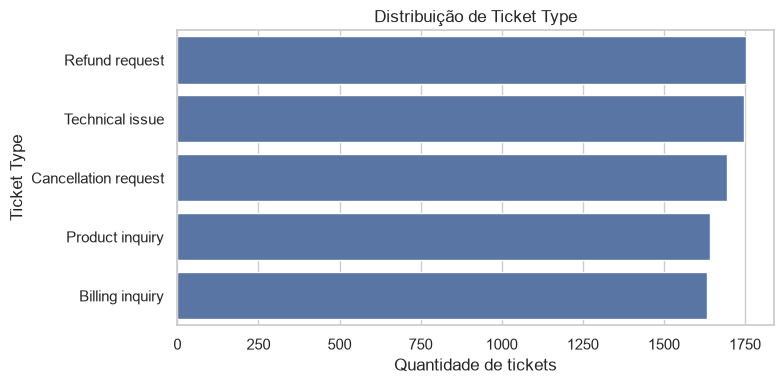

Ticket Type
Refund request          20.7
Technical issue         20.6
Cancellation request    20.0
Product inquiry         19.4
Billing inquiry         19.3
Name: proportion, dtype: float64

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
order = df_clean["Ticket Type"].value_counts().index
sns.countplot(data=df_clean, y="Ticket Type", order=order, ax=ax)
ax.set_title("Distribuição de Ticket Type")
ax.set_xlabel("Quantidade de tickets")
plt.tight_layout()
plt.show()

df_clean["Ticket Type"].value_counts(normalize=True).mul(100).round(1)


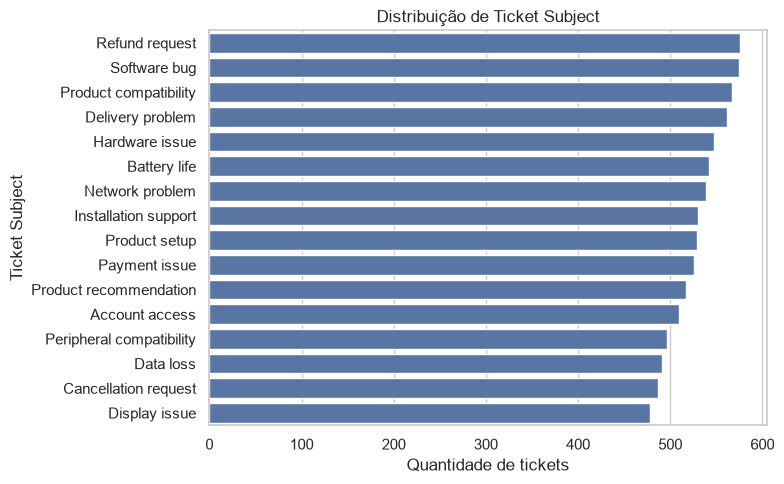

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
order = df_clean["Ticket Subject"].value_counts().index
sns.countplot(data=df_clean, y="Ticket Subject", order=order, ax=ax)
ax.set_title("Distribuição de Ticket Subject")
ax.set_xlabel("Quantidade de tickets")
plt.tight_layout()
plt.show()


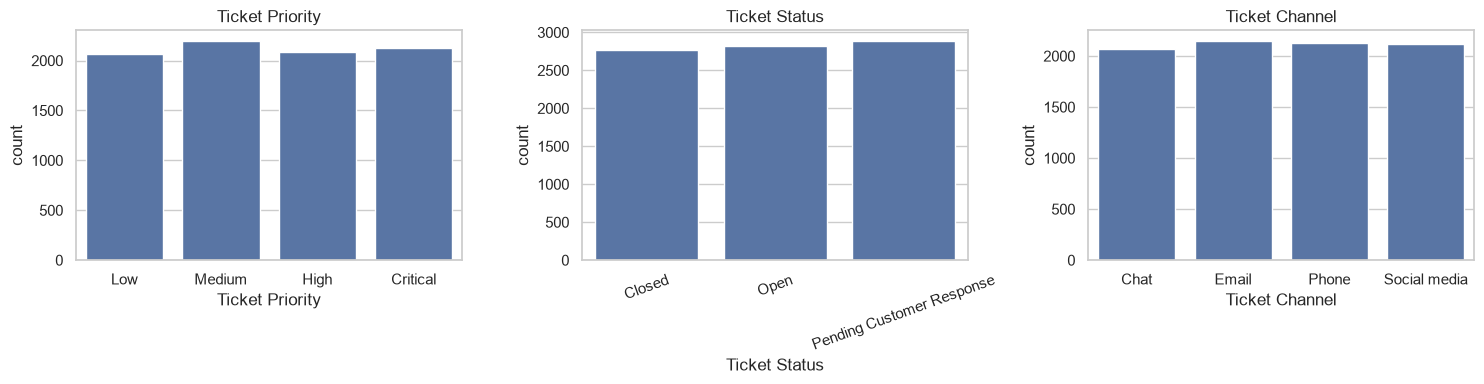

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df_clean, x="Ticket Priority",
              order=["Low", "Medium", "High", "Critical"], ax=axes[0])
axes[0].set_title("Ticket Priority")
sns.countplot(data=df_clean, x="Ticket Status", ax=axes[1])
axes[1].set_title("Ticket Status")
axes[1].tick_params(axis="x", rotation=20)
sns.countplot(data=df_clean, x="Ticket Channel", ax=axes[2])
axes[2].set_title("Ticket Channel")
plt.tight_layout()
plt.show()


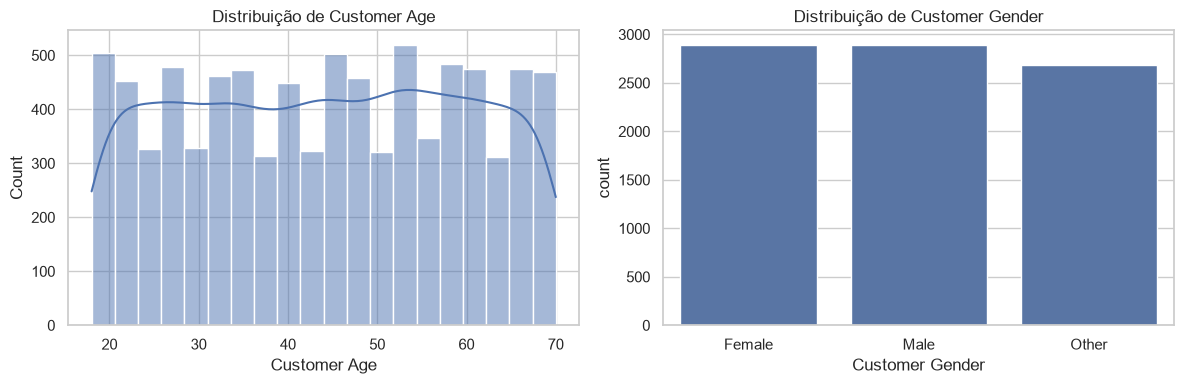

count    8469.000000
mean       44.026804
std        15.296112
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Customer Age, dtype: float64

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df_clean, x="Customer Age", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Distribuição de Customer Age")
sns.countplot(data=df_clean, x="Customer Gender", ax=axes[1])
axes[1].set_title("Distribuição de Customer Gender")
plt.tight_layout()
plt.show()

df_clean["Customer Age"].describe()


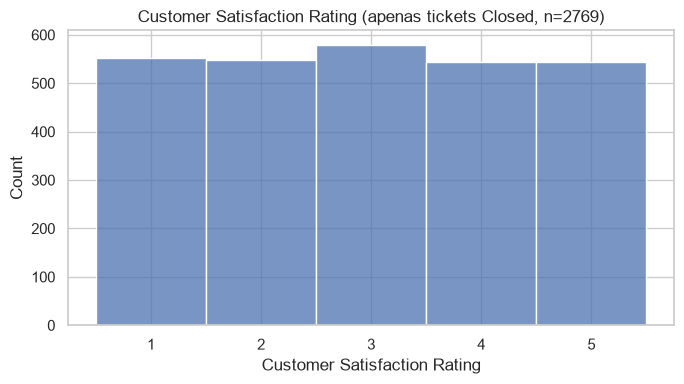

count    2769.000000
mean        2.991333
std         1.407016
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Customer Satisfaction Rating, dtype: float64

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df_clean, x="Customer Satisfaction Rating", bins=5, discrete=True, ax=ax)
ax.set_title("Customer Satisfaction Rating (apenas tickets Closed, n=2769)")
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

df_clean["Customer Satisfaction Rating"].describe()


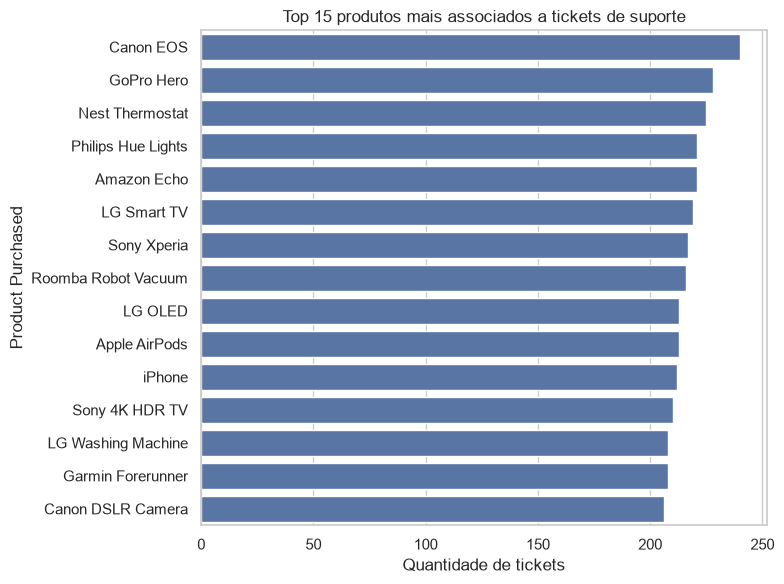

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
top_products = df_clean["Product Purchased"].value_counts().head(15)
sns.barplot(x=top_products.values, y=top_products.index, ax=ax)
ax.set_title("Top 15 produtos mais associados a tickets de suporte")
ax.set_xlabel("Quantidade de tickets")
plt.tight_layout()
plt.show()


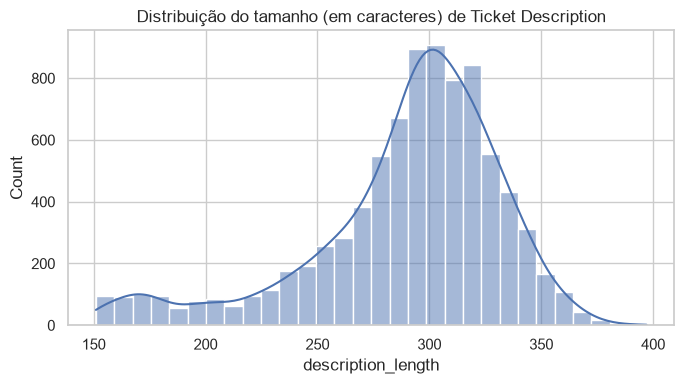

count    8469.000000
mean      289.821939
std        43.593954
min       151.000000
25%       273.000000
50%       298.000000
75%       318.000000
max       397.000000
Name: description_length, dtype: float64

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df_clean, x="description_length", bins=30, kde=True, ax=ax)
ax.set_title("Distribuição do tamanho (em caracteres) de Ticket Description")
plt.tight_layout()
plt.show()

df_clean["description_length"].describe()


## 6. Hipóteses sobre as "intenções" dos usuários

A partir dos padrões observados na análise univariada acima, foram formuladas as
seguintes hipóteses:

**H1 — A distribuição de intenções é artificialmente balanceada.**
As cinco categorias de `Ticket Type` aparecem em proporções muito próximas
(entre 19,3% e 20,7% cada — Refund request 1.752, Technical issue 1.747,
Cancellation request 1.695, Product inquiry 1.641, Billing inquiry 1.634).
Um volume real de suporte tende a ser desbalanceado (ex.: problemas técnicos
e cobrança normalmente dominam). Esse quase-uniforme balanceamento é um
indício de geração sintética e implica que um classificador de intenção
treinado aqui pode performar pior em produção, onde a distribuição real de
intenções provavelmente é bem mais enviesada e não seguirá essa lógica balanceada.

**H2 — As intenções se agrupam em dois grandes eixos: "algo está quebrado" vs. "algo no pedido/conta precisa mudar".**
Os assuntos mais frequentes de `Ticket Subject` (Software bug, Product
compatibility, Hardware issue, Battery life, Network problem, Display issue,
Installation support, Product setup, Data loss, Peripheral compatibility)
sinalizam intenção de **suporte técnico/troubleshooting**, enquanto outro
grupo (Refund request, Payment issue, Account access, Cancellation request,
Delivery problem, Product recommendation) sinaliza intenção **comercial/de
conta**. Isso sugere que um classificador hierárquico (primeiro "técnico vs.
comercial", depois o assunto específico) pode ser mais robusto do que prever
as 16 classes de uma vez.

**H3 — A intenção precisa ser inferida sem informação de desfecho.**
`Ticket Status` está dividido quase igualmente entre `Pending Customer
Response` (34,0%), `Open` (33,3%) e `Closed` (32,7%), e os campos de
desfecho (`Resolution`, `Time to Resolution`, `Customer Satisfaction
Rating`) só existem para os `Closed`. Isso confirma que, no momento em que a
intenção precisa ser classificada (a chegada do ticket), nenhuma dessas
colunas de desfecho pode existir como feature — reforçando o que já foi
apontado na Seção 1 sobre risco de vazamento de dados.

**H4 — O texto livre carrega boilerplate e pode ter menos sinal do que os campos estruturados.**
As descrições têm em média ~290 caracteres, mas 100% delas contêm o
placeholder de template `{product_purchased}` e frases genéricas repetidas
("Please assist.", "I've tried troubleshooting steps mentioned in the user
manual..."). Isso sugere que, pelo menos neste dataset sintético, sinais
estruturados como `Product Purchased` e `Ticket Channel` podem ser tão ou
mais informativos da intenção do usuário do que o texto livre em si —
algo a validar quando o classificador de `/predict` for treinado de fato.
